In [1]:
import os
import hashlib
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# NOTE: adjust DATA_DIR if your folder layout differs.
# Expected structure (matches the Progress Review I repo layout):
#   data/raw/Training/<class_name>/*.jpg
#   data/raw/Testing/<class_name>/*.jpg
DATA_DIR = "../data/raw"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", CLASSES)

Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [2]:
def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            counts[cls] = len(files)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training set:", train_counts, "| total:", sum(train_counts.values()))
print("Testing set: ", test_counts, "| total:", sum(test_counts.values()))

Training set: {'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827} | total: 2870
Testing set:  {'glioma_tumor': 100, 'meningioma_tumor': 115, 'no_tumor': 105, 'pituitary_tumor': 74} | total: 394


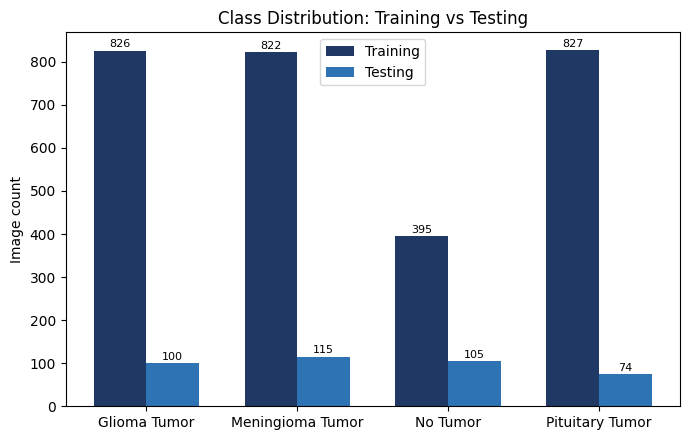

In [3]:
labels = [c.replace("_", " ").title() for c in CLASSES]
train_vals = [train_counts[c] for c in CLASSES]
test_vals = [test_counts[c] for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, train_vals, width, label="Training", color="#1F3864")
ax.bar(x + width/2, test_vals, width, label="Testing", color="#2E74B5")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Image count")
ax.set_title("Class Distribution: Training vs Testing")
ax.legend()
for i, v in enumerate(train_vals):
    ax.text(i - width/2, v + 8, str(v), ha="center", fontsize=8)
for i, v in enumerate(test_vals):
    ax.text(i + width/2, v + 8, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../results/eda_visualizations/class_distribution.png", dpi=150)
plt.show()

In [4]:
def collect_sizes(folder):
    sizes = Counter()
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            fp = os.path.join(cls_path, f)
            try:
                with Image.open(fp) as img:
                    sizes[img.size] += 1
            except Exception:
                pass
    return sizes

train_sizes = collect_sizes(TRAIN_DIR)
test_sizes = collect_sizes(TEST_DIR)
all_sizes = train_sizes + test_sizes

total_images = sum(all_sizes.values())
most_common_size, most_common_count = all_sizes.most_common(1)[0]
min_dim_size = min(all_sizes, key=lambda s: s[0] * s[1])
max_dim_size = max(all_sizes, key=lambda s: s[0] * s[1])

print(f"Total images inspected: {total_images}")
print(f"Distinct image dimensions found: {len(all_sizes)}")
print(f"Most common size: {most_common_size} "
      f"({most_common_count} images, {most_common_count/total_images:.1%})")
print(f"Smallest image (by area): {min_dim_size}")
print(f"Largest image (by area):  {max_dim_size}")
print("Top 5 sizes:", all_sizes.most_common(5))

Total images inspected: 3264
Distinct image dimensions found: 440
Most common size: (512, 512) (2341 images, 71.7%)
Smallest image (by area): (175, 167)
Largest image (by area):  (1375, 1446)
Top 5 sizes: [((512, 512), 2341), ((236, 236), 79), ((225, 225), 43), ((442, 442), 22), ((256, 256), 18)]


In [5]:
def check_corrupt_and_duplicates(folders):
    corrupt = []
    hashes = {}
    duplicate_files = []
    total = 0
    for folder in folders:
        for cls in os.listdir(folder):
            cls_path = os.path.join(folder, cls)
            if not os.path.isdir(cls_path):
                continue
            for f in os.listdir(cls_path):
                fp = os.path.join(cls_path, f)
                total += 1
                try:
                    with Image.open(fp) as img:
                        img.verify()
                except Exception:
                    corrupt.append(fp)
                try:
                    with open(fp, "rb") as fh:
                        h = hashlib.md5(fh.read()).hexdigest()
                    if h in hashes:
                        duplicate_files.append((fp, hashes[h]))
                    else:
                        hashes[h] = fp
                except Exception:
                    pass
    return total, corrupt, duplicate_files

total, corrupt_files, duplicate_files = check_corrupt_and_duplicates([TRAIN_DIR, TEST_DIR])

print(f"Total images scanned: {total}")
print(f"Corrupt / unreadable files: {len(corrupt_files)}")
print(f"Exact duplicate files (MD5 match): {len(duplicate_files)} "
      f"({len(duplicate_files)/total:.1%} of dataset)")
if duplicate_files[:3]:
    print("Example duplicate pairs:", duplicate_files[:3])

Total images scanned: 3264
Corrupt / unreadable files: 0
Exact duplicate files (MD5 match): 237 (7.3% of dataset)
Example duplicate pairs: [('../data/raw/Training/pituitary_tumor/p (579).jpg', '../data/raw/Training/pituitary_tumor/p (578).jpg'), ('../data/raw/Training/pituitary_tumor/p (567).jpg', '../data/raw/Training/pituitary_tumor/p (565).jpg'), ('../data/raw/Training/pituitary_tumor/p (197).jpg', '../data/raw/Training/pituitary_tumor/p (196).jpg')]


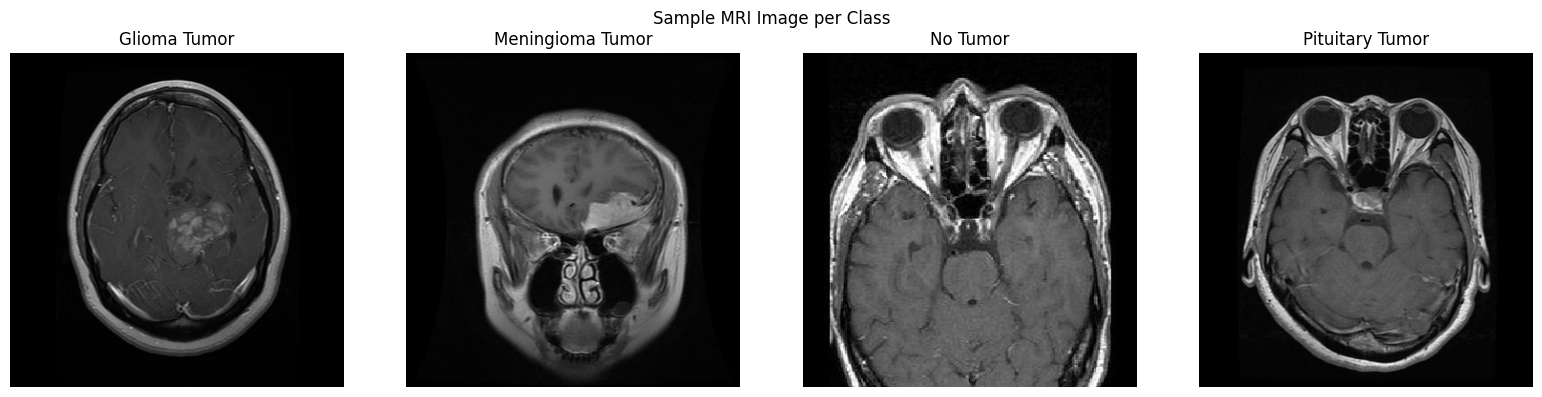

In [6]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))
for ax, cls in zip(axes, CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample_file = sorted(os.listdir(cls_path))[0]
    img = Image.open(os.path.join(cls_path, sample_file))
    ax.imshow(img, cmap="gray")
    ax.set_title(cls.replace("_", " ").title())
    ax.axis("off")
plt.suptitle("Sample MRI Image per Class")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/sample_grid.png", dpi=150)
plt.show()

In [7]:
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)

def load_and_preprocess(filepath):
    """Load an MRI image and apply the full preprocessing pipeline
    expected by DenseNet121: resize -> RGB -> DenseNet121 normalization."""
    img = Image.open(filepath).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img).astype("float32")
    # NOTE: preprocess_input can modify its input array in place, so we pass
    # a copy to keep an unmodified "raw" version for before/after comparison.
    normalized = preprocess_input(arr.copy())
    return arr, normalized

# Demonstrate on one sample image
sample_cls = CLASSES[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls, sorted(os.listdir(os.path.join(TRAIN_DIR, sample_cls)))[0])
raw_arr, norm_arr = load_and_preprocess(sample_path)

print("Raw pixel value range:        min=%.2f  max=%.2f  mean=%.2f" %
      (raw_arr.min(), raw_arr.max(), raw_arr.mean()))
print("Normalized pixel value range: min=%.2f  max=%.2f  mean=%.2f" %
      (norm_arr.min(), norm_arr.max(), norm_arr.mean()))

I0000 00:00:1789310478.535370     396 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789310478.578864     396 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789310480.034210     396 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Raw pixel value range:        min=0.00  max=233.00  mean=26.84
Normalized pixel value range: min=-2.12  max=2.26  mean=-1.52


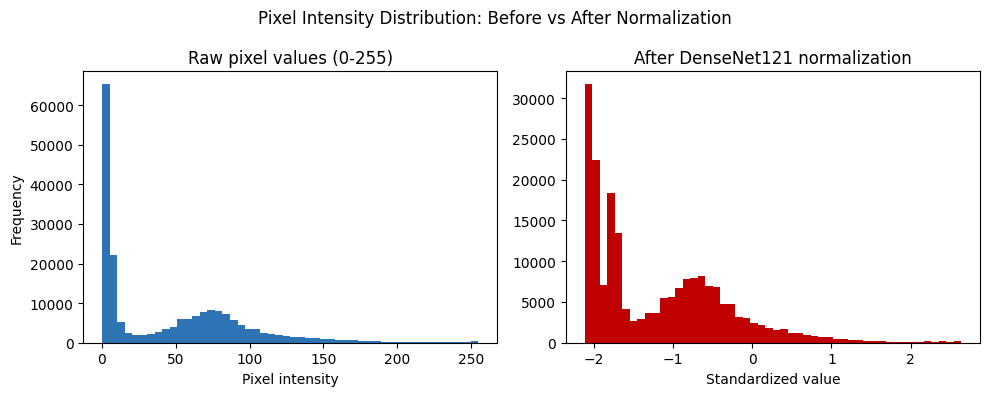

In [8]:
rng = np.random.default_rng(0)
raw_samples = []
norm_samples = []

for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    files = sorted(os.listdir(cls_path))[:15]  # small sample per class for speed
    for f in files:
        raw_arr, norm_arr = load_and_preprocess(os.path.join(cls_path, f))
        raw_samples.append(raw_arr.flatten())
        norm_samples.append(norm_arr.flatten())

raw_samples = np.concatenate(raw_samples)
norm_samples = np.concatenate(norm_samples)

# Subsample for a fast, readable histogram
n = min(200_000, raw_samples.size)
raw_sub = rng.choice(raw_samples, size=n, replace=False)
norm_sub = rng.choice(norm_samples, size=n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw_sub, bins=50, color="#2E74B5")
axes[0].set_title("Raw pixel values (0-255)")
axes[0].set_xlabel("Pixel intensity")
axes[0].set_ylabel("Frequency")

axes[1].hist(norm_sub, bins=50, color="#C00000")
axes[1].set_title("After DenseNet121 normalization")
axes[1].set_xlabel("Standardized value")

plt.suptitle("Pixel Intensity Distribution: Before vs After Normalization")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/pixel_intensity_before_after.png", dpi=150)
plt.show()

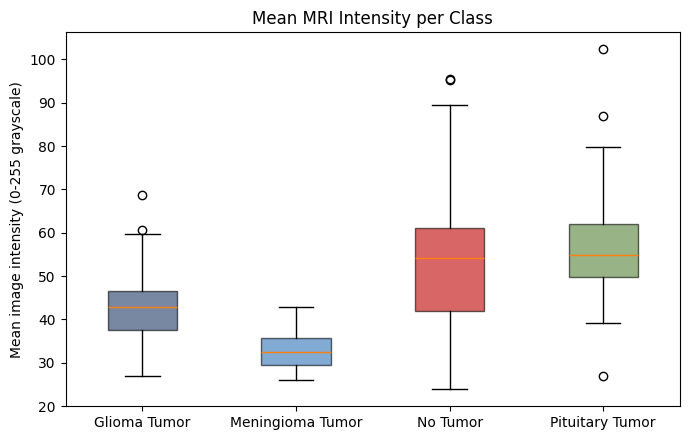

glioma_tumor: mean=43.02  std=8.25  min=26.85  max=68.83
meningioma_tumor: mean=32.94  std=4.36  min=26.01  max=42.81
no_tumor: mean=54.12  std=16.87  min=23.88  max=95.44
pituitary_tumor: mean=56.60  std=11.89  min=26.88  max=102.33


In [9]:
class_means = {c: [] for c in CLASSES}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    files = sorted(os.listdir(cls_path))[:60]
    for f in files:
        img = Image.open(os.path.join(cls_path, f)).convert("L")
        arr = np.array(img).astype("float32")
        class_means[cls].append(arr.mean())

fig, ax = plt.subplots(figsize=(7, 4.5))
data = [class_means[c] for c in CLASSES]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
colors = ["#1F3864", "#2E74B5", "#C00000", "#548235"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Mean image intensity (0-255 grayscale)")
ax.set_title("Mean MRI Intensity per Class")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/intensity_boxplot.png", dpi=150)
plt.show()

for cls, vals in class_means.items():
    v = np.array(vals)
    print(f"{cls}: mean={v.mean():.2f}  std={v.std():.2f}  min={v.min():.2f}  max={v.max():.2f}")